### Required Discussion 16.1: Comparing Models

Now that you have seen a variety of models for regression and classification problems, it is good to step back and weigh the pros and cons of these options.  In the case of classification models, there are at least three things to consider:

1. Is the model good at handling imbalanced classes?
2. Does the model train quickly?
3. Does the model yield interpretable results?

Depending on your dataset and goals, the importance of these considerations will vary from project to project.  Your goal is to review our models to this point and discuss the pros and cons of each.  Two example datasets are offered as a way to offer two very different tasks where interpretability of the model may be of differing importance.

### Data and Task

Your goal is to discuss the pros and cons of Logistic Regression, Decision Trees, KNN, and SVM for the tasks below.  Consider at least the three questions above and list any additional considerations you believe are important to determining the "best" model for the task.  Share your response with your peers on the class discussion board.  

**TASK 1**: Predicting Customer Churn

Suppose you are tasked with producing a model to predict customer churn.  Which of your classification models would you use and what are the pros and cons of this model for this task?  Be sure to consider interpretability, imbalnced classes, and the speed of training.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_digits

The data is loaded below.  Note that the handwritten digit data is already split into features and target (`digits`, `labels`). 

In [3]:
churn = pd.read_csv('data/telecom_churn.csv')
digits, labels = load_digits(return_X_y=True)

In [4]:
#churn data
churn.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


**TASK 2**: Recognizing Handwritten Digits

Suppose you are tasked with training a model to recognize handwritten digits.  Which of your classifier would you use here and why?  Again, be sure to consider the balance of classes, speed of training, and importance of interpretability.



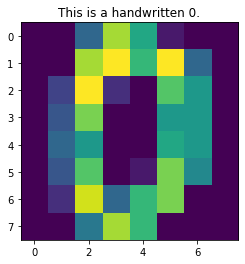

In [7]:
#example image
plt.imshow(digits[0].reshape(8, 8))
plt.title('This is a handwritten 0.');

---
## Part 1: Setup and Imports

**Reference**: ML_Reference_Guide - Section 1

We start by importing all necessary libraries for data manipulation, visualization, preprocessing, 
modeling, and evaluation. This consolidated import section ensures we have everything needed for 
the progressive analysis.

In [5]:
# =============================================================================
# COMPREHENSIVE IMPORTS FOR ML ANALYSIS
# Reference: ML_Reference_Guide - Section 1
# =============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np
import time  # For measuring model training time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Machine Learning - Models (Limited to course curriculum)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

# Machine Learning - Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn import set_config

# Display settings
set_config(display="diagram")
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

print("All imports successful!")

All imports successful!


---
# TASK 1: Predicting Customer Churn

## 1.1 Data Loading and Initial Exploration

**Reference**: ML_Reference_Guide - Section 2

Before building any model, we must understand our data. This includes:
- Shape and structure of the dataset
- Data types of each feature
- Missing values
- Target variable distribution (critical for understanding class imbalance)

In [6]:
# =============================================================================
# LOAD AND INSPECT THE CHURN DATA
# =============================================================================

# Load the telecom churn dataset
churn = pd.read_csv('data/telecom_churn.csv')

# Basic dataset information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset Shape: {churn.shape[0]} rows, {churn.shape[1]} columns")
print(f"\nColumn Names:\n{list(churn.columns)}")

# Data types - important for understanding which features need encoding
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(churn.dtypes)

DATASET OVERVIEW

Dataset Shape: 3333 rows, 20 columns

Column Names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

DATA TYPES
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minute

In [7]:
# =============================================================================
# FIRST LOOK AT THE DATA
# =============================================================================

# Preview first few rows to understand the data structure
print("First 5 rows of the dataset:")
churn.head()

First 5 rows of the dataset:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [8]:
# =============================================================================
# STATISTICAL SUMMARY OF NUMERIC FEATURES
# =============================================================================

# This helps us understand the scale and distribution of numeric features
# Note: Large differences in scales suggest StandardScaler will be needed
print("Statistical Summary:")
churn.describe()

Statistical Summary:


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [9]:
# =============================================================================
# CHECK FOR MISSING VALUES
# Reference: ML_Reference_Guide - Section 3.1
# =============================================================================

# Missing values can cause models to fail - we need to handle them before modeling
missing_vals = churn.isnull().sum()
print("Missing Values per Column:")
print(missing_vals)
print(f"\nTotal Missing Values: {missing_vals.sum()}")

# COMMENT: This dataset appears to have no missing values, so we can proceed
# without imputation. In practice, we would use fillna() or dropna() if needed.

Missing Values per Column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Total Missing Values: 0


## 1.2 Target Variable Analysis - Understanding Class Imbalance

**This directly addresses Discussion Question 1: "Is the model good at handling imbalanced classes?"**

Class imbalance is critical in churn prediction because:
- Typically, far fewer customers churn than stay
- A model that predicts "no churn" for everyone might have high accuracy but miss all churners
- We need metrics beyond accuracy (F1, precision, recall) to properly evaluate models

In [10]:
# =============================================================================
# TARGET VARIABLE DISTRIBUTION (Churn)
# Reference: ML_Reference_Guide - Section 4.1
# =============================================================================

# Check the distribution of the target variable
print("Target Variable Distribution:")
print("=" * 40)
target_counts = churn['Churn'].value_counts()
target_pct = churn['Churn'].value_counts(normalize=True) * 100

print("\nAbsolute Counts:")
print(target_counts)
print("\nPercentage Distribution:")
print(target_pct.round(2))

# Calculate imbalance ratio
majority_class = target_counts.max()
minority_class = target_counts.min()
imbalance_ratio = majority_class / minority_class
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")

# COMMENT: This imbalance ratio tells us how many times more frequent the 
# majority class is compared to the minority. A ratio > 3:1 is typically 
# considered imbalanced and requires special handling (class_weight parameter).

Target Variable Distribution:

Absolute Counts:
Churn
False    2850
True      483
Name: count, dtype: int64

Percentage Distribution:
Churn
False    85.51
True     14.49
Name: proportion, dtype: float64

Class Imbalance Ratio: 5.90:1


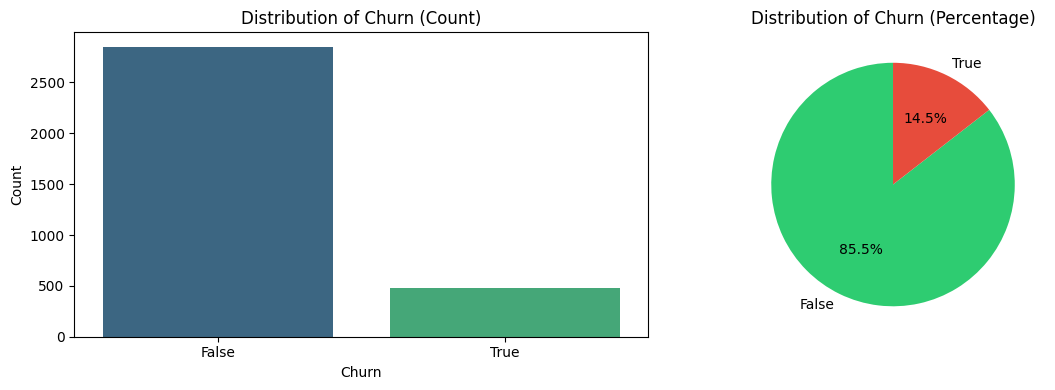

In [11]:
# =============================================================================
# VISUALIZE CLASS IMBALANCE
# Reference: ML_Reference_Guide - Section 4.1
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=churn, x='Churn', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Churn (Count)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

# Pie chart for proportions
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Distribution of Churn (Percentage)')

plt.tight_layout()
plt.savefig('churn_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# COMMENT: Visual confirmation of class imbalance. The minority class (churners)
# represents a small portion of the data, making this a challenging classification task.

## 1.3 Feature Analysis - Understanding Feature Types

**Reference**: ML_Reference_Guide - Section 5

Before preprocessing, we need to identify:
1. **Categorical features**: Require encoding (OneHotEncoder or LabelEncoder)
2. **Numerical features**: May require scaling (StandardScaler)

**Industry Standard Note**: We will exclude features that are likely redundant or less useful:
- `State`: 50 unique values creates sparse encoding (can try but may hurt simple models)
- `Area code`: Categorical but limited predictive value (only 3 values)
- Charge columns: Highly correlated with minutes (derived from minutes × rate)

In [12]:
# =============================================================================
# IDENTIFY CATEGORICAL vs NUMERICAL FEATURES
# =============================================================================

# Examine unique values for object (string) columns
print("CATEGORICAL FEATURE ANALYSIS:")
print("=" * 60)

categorical_cols = churn.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {churn[col].nunique()}")
    print(f"  Values: {churn[col].unique()[:10]}...")  # Show first 10

# Numerical columns
numerical_cols = churn.select_dtypes(include=[np.number]).columns.tolist()
print("\n" + "=" * 60)
print(f"NUMERICAL FEATURES ({len(numerical_cols)} columns):")
print(numerical_cols)

CATEGORICAL FEATURE ANALYSIS:

State:
  Unique values: 51
  Values: ['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'LA' 'WV' 'IN']...

International plan:
  Unique values: 2
  Values: ['No' 'Yes']...

Voice mail plan:
  Unique values: 2
  Values: ['Yes' 'No']...

Churn:
  Unique values: 2
  Values: [False  True]...

NUMERICAL FEATURES (16 columns):
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [13]:
# =============================================================================
# CORRELATION ANALYSIS - Identify Redundant Features
# Reference: ML_Reference_Guide - Section 4.3
# =============================================================================

# COMMENT: We check correlations to avoid multicollinearity and reduce features
# Industry standard: Features with correlation > 0.9 are typically redundant

# Convert boolean target to numeric for correlation
churn_numeric = churn.copy()
churn_numeric['Churn'] = churn_numeric['Churn'].map({False: 0, True: 1})

# Compute correlation matrix for numeric columns
numeric_df = churn_numeric.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Find highly correlated pairs (> 0.9)
print("HIGHLY CORRELATED FEATURE PAIRS (|correlation| > 0.9):")
print("=" * 60)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: "
                  f"{correlation_matrix.iloc[i, j]:.3f}")

# COMMENT: As expected, "minutes" and "charge" columns are nearly perfectly 
# correlated (charge = minutes × rate). We will drop charge columns to reduce
# redundancy and simplify our models.

HIGHLY CORRELATED FEATURE PAIRS (|correlation| > 0.9):
Total day minutes <-> Total day charge: 1.000
Total eve minutes <-> Total eve charge: 1.000
Total night minutes <-> Total night charge: 1.000
Total intl minutes <-> Total intl charge: 1.000


## 1.4 Data Preprocessing

**Reference**: ML_Reference_Guide - Sections 5.3, 5.4

Steps:
1. **Feature Selection**: Drop redundant/low-value features based on analysis above
2. **Encoding**: Convert categorical variables to numeric (OneHotEncoder for binary Yes/No features)
3. **Scaling**: Standardize numeric features (required for SVM, KNN; helpful for Logistic Regression)
4. **Train-Test Split**: 70-30 split with stratification to preserve class balance

In [14]:
# =============================================================================
# FEATURE SELECTION AND PREPARATION
# Reference: ML_Reference_Guide - Section 5
# =============================================================================

# Create a working copy
df = churn.copy()

# STEP 1: Drop redundant features
# RATIONALE for dropping:
# - State: 50 categories creates sparse encoding, limited predictive value for simple models
# - Area code: Only 3 values, minimal information gain
# - Charge columns: Perfectly correlated with minutes columns (charge = minutes × rate)

columns_to_drop = [
    'State',           # Too many categories (50 unique values)
    'Area code',       # Limited predictive value
    'Total day charge',    # Redundant with Total day minutes
    'Total eve charge',    # Redundant with Total eve minutes  
    'Total night charge',  # Redundant with Total night minutes
    'Total intl charge'    # Redundant with Total intl minutes
]

df = df.drop(columns=columns_to_drop)
print(f"Features after dropping redundant columns: {list(df.columns)}")
print(f"Shape: {df.shape}")

Features after dropping redundant columns: ['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'Churn']
Shape: (3333, 14)


In [15]:
# =============================================================================
# ENCODE CATEGORICAL VARIABLES
# Reference: ML_Reference_Guide - Section 5.3
# =============================================================================

# STEP 2: Encode binary categorical features
# Using simple mapping for Yes/No features (equivalent to LabelEncoder for binary)

# International plan: Yes=1, No=0
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})

# Voice mail plan: Yes=1, No=0
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

# Target variable: True=1, False=0
df['Churn'] = df['Churn'].map({True: 1, False: 0})

print("Encoded categorical variables:")
print(df[['International plan', 'Voice mail plan', 'Churn']].head())

# COMMENT: For binary categorical variables (Yes/No), simple mapping is 
# equivalent to LabelEncoder and more interpretable than OneHotEncoder.
# OneHotEncoder with drop='if_binary' would give the same result.

Encoded categorical variables:
   International plan  Voice mail plan  Churn
0                   0                1      0
1                   0                1      0
2                   0                0      0
3                   1                0      0
4                   1                0      0


In [16]:
# =============================================================================
# TRAIN-TEST SPLIT
# Reference: ML_Reference_Guide - Section 6.1
# =============================================================================

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split with stratification to preserve class balance in both sets
# Using 70-30 split as per course standard
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y  # IMPORTANT: Ensures same class ratio in train and test
)

print("Train-Test Split Results:")
print("=" * 40)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(3))

# COMMENT: Stratified split ensures the class imbalance ratio is preserved
# in both training and test sets, giving us a fair evaluation.

Train-Test Split Results:
Training set: 2333 samples
Test set: 1000 samples

Training set class distribution:
Churn
0    0.855
1    0.145
Name: proportion, dtype: float64

Test set class distribution:
Churn
0    0.855
1    0.145
Name: proportion, dtype: float64


In [17]:
# =============================================================================
# FEATURE SCALING
# Reference: ML_Reference_Guide - Section 5.4
# =============================================================================

# STEP 3: Standardize features
# IMPORTANT: Fit scaler on training data ONLY, then transform both sets
# This prevents data leakage from test set

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled Training Features (first 3 rows):")
print(X_train_scaled.head(3).round(3))

# COMMENT: Scaling is REQUIRED for:
# - SVM: Distance-based, sensitive to feature magnitudes
# - KNN: Distance-based, sensitive to feature magnitudes
# Scaling HELPS for:
# - Logistic Regression: Improves convergence speed
# Decision Trees do NOT need scaling (split-based, not distance-based)

Scaled Training Features (first 3 rows):
      Account length  International plan  Voice mail plan  \
606            0.711              -0.319           -0.629   
2468           1.285               3.139            1.590   
1844          -0.588              -0.319            1.590   

      Number vmail messages  Total day minutes  Total day calls  \
606                  -0.601             -0.745            0.935   
2468                  2.388             -0.610            1.384   
1844                  1.440             -0.812            0.835   

      Total eve minutes  Total eve calls  Total night minutes  \
606               1.721            0.236               -1.426   
2468              1.648           -0.213                0.263   
1844              0.844            0.086                0.141   

      Total night calls  Total intl minutes  Total intl calls  \
606              -0.156               1.009             1.445   
2468             -1.028              -2.088           

---
## 1.5 Model Building and Comparison

**Reference**: ML_Reference_Guide - Sections 14, 16

We will progressively build and compare models from simplest to most complex:
1. **Baseline Model**: Predict majority class (establishes minimum performance)
2. **Logistic Regression**: Simple, interpretable linear classifier
3. **Decision Tree**: Interpretable, handles non-linear relationships
4. **K-Nearest Neighbors (KNN)**: Instance-based, no assumptions about data
5. **Support Vector Machine (SVM)**: Maximum margin classifier with kernel options

For each model, we will track:
- **Training Time** (Discussion Question 2: "Does the model train quickly?")
- **Accuracy, Precision, Recall, F1-Score** (handles imbalance better than accuracy alone)
- **Confusion Matrix** (visualize true/false positives and negatives)

In [18]:
# =============================================================================
# HELPER FUNCTION FOR MODEL EVALUATION
# =============================================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train and evaluate a classification model, returning key metrics.
    
    Returns a dictionary with:
    - Training time
    - Accuracy (train and test)
    - Precision, Recall, F1-Score (test set)
    - Confusion matrix
    """
    results = {'Model': model_name}
    
    # Time the training
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    results['Training Time (s)'] = round(train_time, 4)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    results['Train Accuracy'] = round(accuracy_score(y_train, y_train_pred), 4)
    results['Test Accuracy'] = round(accuracy_score(y_test, y_test_pred), 4)
    results['Precision'] = round(precision_score(y_test, y_test_pred), 4)
    results['Recall'] = round(recall_score(y_test, y_test_pred), 4)
    results['F1-Score'] = round(f1_score(y_test, y_test_pred), 4)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    print(f"Training Time: {results['Training Time (s)']} seconds")
    print(f"Train Accuracy: {results['Train Accuracy']}")
    print(f"Test Accuracy: {results['Test Accuracy']}")
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    results['Confusion Matrix'] = cm
    
    return results, y_test_pred

# Storage for all model results
all_results = []
print("Evaluation function ready!")

Evaluation function ready!


### 1.5.1 Baseline Model (Majority Class Classifier)

**Reference**: ML_Reference_Guide - Section 6.2

A baseline that always predicts the majority class ("No Churn") sets the minimum bar that any real model must beat. This also demonstrates why accuracy alone is misleading for imbalanced datasets.

In [19]:
# =============================================================================
# BASELINE MODEL: Predict Majority Class
# Reference: ML_Reference_Guide - Section 6.2
# =============================================================================

# Find the majority class
majority_class = y_train.mode()[0]
print(f"Majority class: {majority_class} ({'No Churn' if majority_class == 0 else 'Churn'})")

# Create baseline predictions (always predict majority class)
baseline_pred = np.ones(len(y_test)) * majority_class

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print(f"\nBASELINE RESULTS:")
print(f"{'='*40}")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"F1-Score: {baseline_f1:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))

# COMMENT: The baseline achieves ~85% accuracy by always predicting "No Churn"
# BUT the F1-Score is 0 because it never identifies any churners!
# This demonstrates why F1-Score is crucial for imbalanced classification.

Majority class: 0 (No Churn)

BASELINE RESULTS:
Accuracy: 0.8550
F1-Score: 0.0000

Confusion Matrix:
[[855   0]
 [145   0]]


### 1.5.2 Logistic Regression

**Reference**: ML_Reference_Guide - Section 16.1

**Why Logistic Regression for Churn?**
- **Highly Interpretable**: Coefficients show feature importance (key for business decisions)
- **Fast Training**: Scales well to large datasets
- **class_weight='balanced'**: Automatically handles class imbalance
- **Probabilistic Output**: Can set custom decision thresholds

**Limitations**: Assumes linear decision boundary (may miss complex patterns)

In [20]:
# =============================================================================
# MODEL 1: LOGISTIC REGRESSION
# Reference: ML_Reference_Guide - Section 16.1
# =============================================================================

# Version 1: Without class weight (to see the effect of imbalance)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_results, lr_pred = evaluate_model(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 
    "Logistic Regression (default)"
)
all_results.append(lr_results)


MODEL: Logistic Regression (default)
Training Time: 0.0976 seconds
Train Accuracy: 0.8586
Test Accuracy: 0.864

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92       855
       Churn       0.57      0.25      0.35       145

    accuracy                           0.86      1000
   macro avg       0.73      0.61      0.64      1000
weighted avg       0.84      0.86      0.84      1000



In [21]:
# =============================================================================
# MODEL 1b: LOGISTIC REGRESSION WITH CLASS WEIGHT BALANCING
# =============================================================================

# Version 2: With class_weight='balanced' to handle imbalance
# This automatically adjusts weights inversely proportional to class frequencies
lr_balanced = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'  # KEY: Handles class imbalance
)
lr_balanced_results, lr_balanced_pred = evaluate_model(
    lr_balanced, X_train_scaled, X_test_scaled, y_train, y_test, 
    "Logistic Regression (balanced)"
)
all_results.append(lr_balanced_results)

# COMMENT: Notice how class_weight='balanced' improves Recall (catching more churners)
# at the cost of slightly lower Precision. This trade-off is often worthwhile
# in churn prediction where missing a churner is costly.


MODEL: Logistic Regression (balanced)
Training Time: 0.0117 seconds
Train Accuracy: 0.772
Test Accuracy: 0.764

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.94      0.77      0.85       855
       Churn       0.35      0.73      0.47       145

    accuracy                           0.76      1000
   macro avg       0.65      0.75      0.66      1000
weighted avg       0.86      0.76      0.79      1000



LOGISTIC REGRESSION FEATURE IMPORTANCE (Coefficients):
Positive coefficients increase churn probability.
Negative coefficients decrease churn probability.

               Feature  Coefficient
Customer service calls     0.776908
    International plan     0.683591
     Total day minutes     0.629959
 Number vmail messages     0.540796
     Total eve minutes     0.327767
    Total intl minutes     0.216913
   Total night minutes     0.128330
       Total eve calls     0.086695
        Account length     0.070370
       Total day calls     0.037300
     Total night calls    -0.011654
      Total intl calls    -0.297121
       Voice mail plan    -0.889197


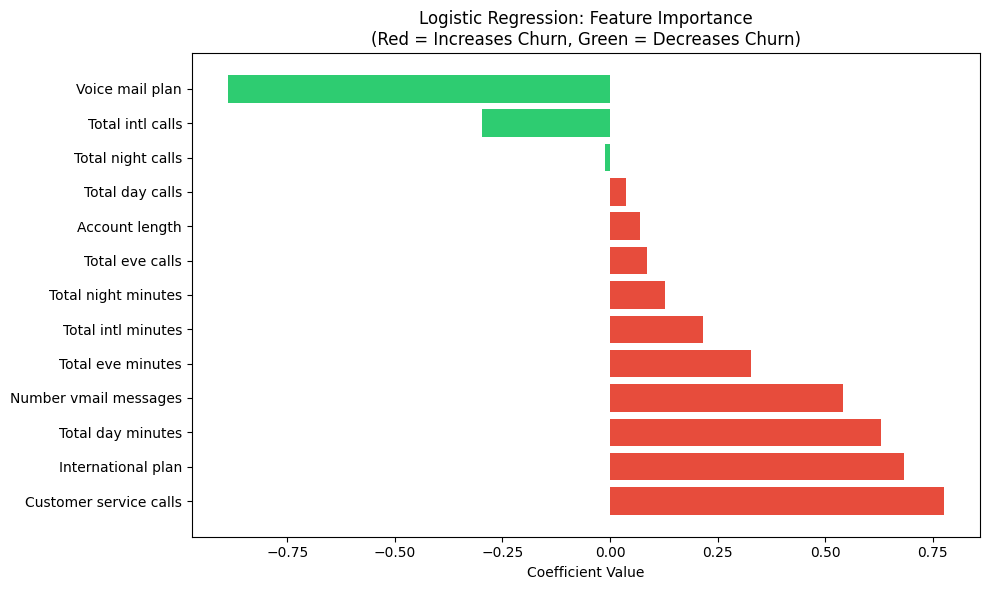

In [22]:
# =============================================================================
# LOGISTIC REGRESSION: INTERPRETABILITY (Feature Coefficients)
# Reference: Discussion Question 3 - "Does the model yield interpretable results?"
# =============================================================================

# Get coefficients from the balanced model
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_balanced.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("LOGISTIC REGRESSION FEATURE IMPORTANCE (Coefficients):")
print("=" * 60)
print("Positive coefficients increase churn probability.")
print("Negative coefficients decrease churn probability.\n")
print(coef_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression: Feature Importance\n(Red = Increases Churn, Green = Decreases Churn)')
plt.tight_layout()
plt.savefig('lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# COMMENT: This interpretability is a MAJOR advantage of Logistic Regression.
# Business can clearly see that "Customer service calls" strongly predicts churn,
# while having a "Voice mail plan" decreases churn risk.

### 1.5.3 Decision Tree Classifier

**Reference**: ML_Reference_Guide - Section 14

**Why Decision Trees for Churn?**
- **Highly Interpretable**: Can visualize the tree and explain decisions as rules
- **Handles Non-linear Relationships**: No assumptions about data distribution
- **No Scaling Required**: Split-based, not distance-based
- **class_weight='balanced'**: Can handle class imbalance
- **Fast Training**: Generally quick to train

**Limitations**: 
- Prone to overfitting without pruning (max_depth, min_samples_leaf)
- Unstable (small data changes can significantly alter the tree)

In [23]:
# =============================================================================
# MODEL 2: DECISION TREE (Default - likely overfitting)
# Reference: ML_Reference_Guide - Section 14.1
# =============================================================================

# Note: Using unscaled data for Decision Trees (scaling not required)
dt_model = DecisionTreeClassifier(random_state=42)
dt_results, dt_pred = evaluate_model(
    dt_model, X_train, X_test, y_train, y_test, 
    "Decision Tree (default)"
)
all_results.append(dt_results)

# Check tree depth to understand potential overfitting
print(f"\nTree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")

# COMMENT: An unbounded tree likely overfits. High train accuracy with lower
# test accuracy confirms this. We need to prune the tree.


MODEL: Decision Tree (default)
Training Time: 0.0775 seconds
Train Accuracy: 1.0
Test Accuracy: 0.914

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.95      0.95      0.95       855
       Churn       0.71      0.69      0.70       145

    accuracy                           0.91      1000
   macro avg       0.83      0.82      0.82      1000
weighted avg       0.91      0.91      0.91      1000


Tree Depth: 20
Number of Leaves: 136


In [24]:
# =============================================================================
# MODEL 2b: DECISION TREE (Pruned + Balanced)
# Reference: ML_Reference_Guide - Section 14.3
# =============================================================================

# Apply constraints to prevent overfitting and handle class imbalance
dt_pruned = DecisionTreeClassifier(
    max_depth=5,           # Limit tree depth
    min_samples_split=20,  # Minimum samples to create a split
    min_samples_leaf=10,   # Minimum samples in a leaf
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)
dt_pruned_results, dt_pruned_pred = evaluate_model(
    dt_pruned, X_train, X_test, y_train, y_test, 
    "Decision Tree (pruned, balanced)"
)
all_results.append(dt_pruned_results)

print(f"\nPruned Tree Depth: {dt_pruned.get_depth()}")
print(f"Number of Leaves: {dt_pruned.get_n_leaves()}")

# COMMENT: Pruning reduces overfitting (closer train/test accuracy) and
# class_weight='balanced' improves recall for the minority class.


MODEL: Decision Tree (pruned, balanced)
Training Time: 0.0247 seconds
Train Accuracy: 0.9211
Test Accuracy: 0.889

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.96      0.90      0.93       855
       Churn       0.59      0.80      0.68       145

    accuracy                           0.89      1000
   macro avg       0.77      0.85      0.80      1000
weighted avg       0.91      0.89      0.90      1000


Pruned Tree Depth: 5
Number of Leaves: 26


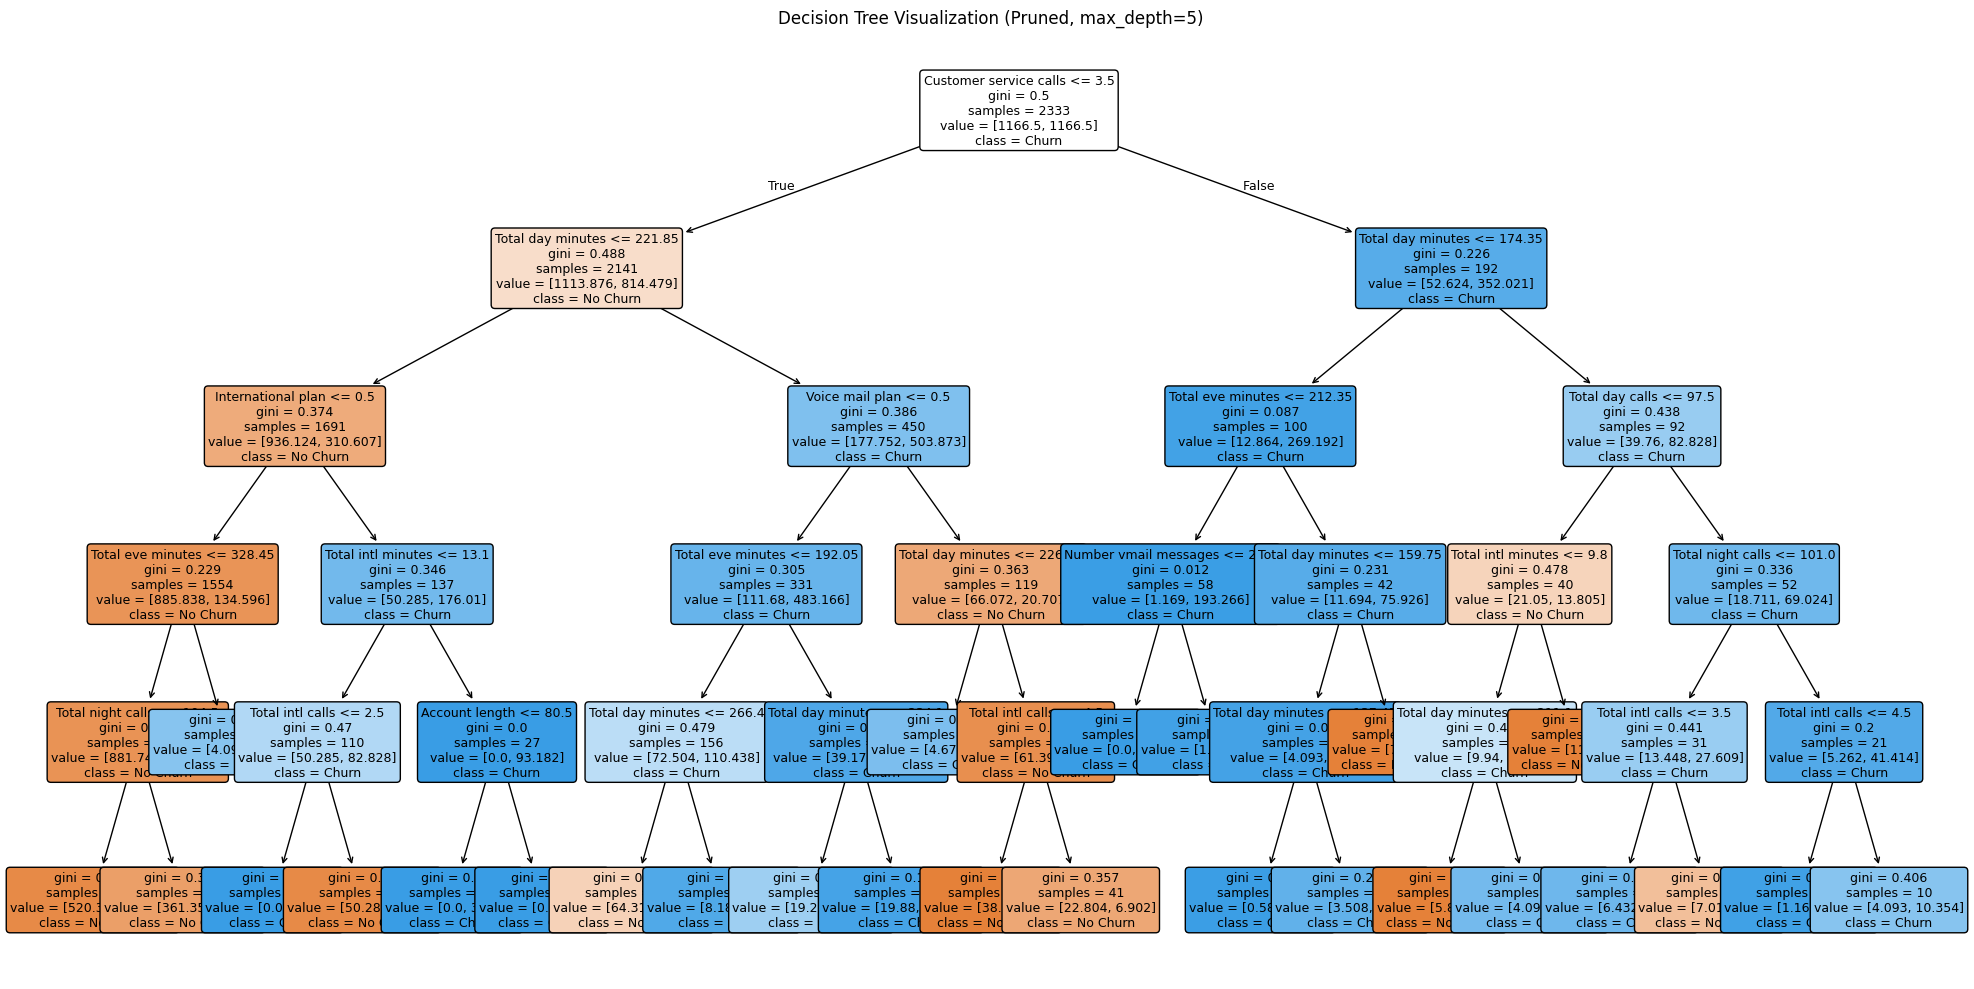

In [25]:
# =============================================================================
# DECISION TREE VISUALIZATION (Interpretability)
# Reference: ML_Reference_Guide - Section 14.1
# =============================================================================

plt.figure(figsize=(20, 10))
plot_tree(
    dt_pruned, 
    feature_names=X_train.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree Visualization (Pruned, max_depth=5)')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# COMMENT: This visual interpretability is a key advantage of Decision Trees.
# Business stakeholders can follow the decision path to understand predictions.
# Each node shows the splitting condition, Gini impurity, and class distribution.

### 1.5.4 K-Nearest Neighbors (KNN)

**Reference**: ML_Reference_Guide - Section 16.5 (Model Comparison)

**Why KNN for Churn?**
- **Non-parametric**: Makes no assumptions about data distribution
- **Simple Concept**: Classifies based on similarity to neighbors
- **No Training Time**: Model is the data itself (lazy learner)
- **Can Handle Non-linear Boundaries**: Naturally captures complex patterns

**Limitations**:
- **Slow Prediction**: Must compute distances to all training samples at prediction time
- **Requires Scaling**: Distance-based, sensitive to feature magnitudes
- **Not Interpretable**: Cannot explain why a prediction was made
- **Memory Intensive**: Stores entire training set
- **Imbalance Issues**: Majority class dominates voting in imbalanced data

In [26]:
# =============================================================================
# MODEL 3: K-NEAREST NEIGHBORS (Default k=5)
# =============================================================================

# KNN requires scaled features (distance-based algorithm)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results, knn_pred = evaluate_model(
    knn_model, X_train_scaled, X_test_scaled, y_train, y_test, 
    "KNN (k=5)"
)
all_results.append(knn_results)

# COMMENT: KNN has NO training time (lazy learner), but prediction is slow
# because it computes distances to all training points. The "Training Time"
# shown is just the time to store the data.


MODEL: KNN (k=5)
Training Time: 0.016 seconds
Train Accuracy: 0.922
Test Accuracy: 0.898

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.90      0.99      0.94       855
       Churn       0.84      0.37      0.51       145

    accuracy                           0.90      1000
   macro avg       0.87      0.68      0.73      1000
weighted avg       0.89      0.90      0.88      1000



In [27]:
# =============================================================================
# MODEL 3b: KNN WITH DISTANCE WEIGHTING
# =============================================================================

# Using distance weighting: closer neighbors have more influence
# This can help with class imbalance as nearby minority samples have stronger votes
knn_weighted = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance'  # Weight votes by inverse distance
)
knn_weighted_results, knn_weighted_pred = evaluate_model(
    knn_weighted, X_train_scaled, X_test_scaled, y_train, y_test, 
    "KNN (k=7, distance weighted)"
)
all_results.append(knn_weighted_results)

# COMMENT: Distance weighting gives closer neighbors more influence, which can
# help when minority class samples are clustered together. However, KNN does
# not have a direct class_weight parameter like other models.


MODEL: KNN (k=7, distance weighted)
Training Time: 0.0058 seconds
Train Accuracy: 1.0
Test Accuracy: 0.892

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.89      0.99      0.94       855
       Churn       0.85      0.31      0.45       145

    accuracy                           0.89      1000
   macro avg       0.87      0.65      0.70      1000
weighted avg       0.89      0.89      0.87      1000



### 1.5.5 Support Vector Machine (SVM)

**Reference**: ML_Reference_Guide - Section 16.3

**Why SVM for Churn?**
- **Maximum Margin**: Finds optimal separating hyperplane
- **Kernel Trick**: Can model complex non-linear boundaries efficiently
- **Handles High Dimensions**: Works well when features > samples
- **class_weight='balanced'**: Can handle class imbalance

**Limitations**:
- **Slow Training**: O(n²) to O(n³) complexity, poor for large datasets
- **Requires Scaling**: Sensitive to feature magnitudes
- **Not Interpretable**: Kernel SVMs are essentially black boxes
- **Memory Intensive**: Must store support vectors

**Kernels Available**:
- **Linear**: Linear decision boundary
- **Polynomial**: Curved boundaries, degree controls complexity
- **RBF (Gaussian)**: Most flexible, captures complex patterns

In [28]:
# =============================================================================
# MODEL 4: SVM WITH LINEAR KERNEL
# Reference: ML_Reference_Guide - Section 16.3
# =============================================================================

# Linear SVM - similar to logistic regression but maximizes margin
svm_linear = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)
svm_linear_results, svm_linear_pred = evaluate_model(
    svm_linear, X_train_scaled, X_test_scaled, y_train, y_test, 
    "SVM (linear kernel, balanced)"
)
all_results.append(svm_linear_results)

# COMMENT: Notice the training time is longer than Logistic Regression.
# Linear SVM often gives similar results to Logistic Regression but is slower.


MODEL: SVM (linear kernel, balanced)
Training Time: 0.1282 seconds
Train Accuracy: 0.7613
Test Accuracy: 0.757

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.95      0.76      0.84       855
       Churn       0.35      0.76      0.48       145

    accuracy                           0.76      1000
   macro avg       0.65      0.76      0.66      1000
weighted avg       0.86      0.76      0.79      1000



In [29]:
# =============================================================================
# MODEL 4b: SVM WITH RBF KERNEL (Most Flexible)
# Reference: ML_Reference_Guide - Section 16.3
# =============================================================================

# RBF (Radial Basis Function) kernel - captures complex non-linear patterns
svm_rbf = SVC(
    kernel='rbf',
    C=1.0,                # Regularization parameter
    gamma='scale',        # Kernel coefficient
    class_weight='balanced',
    random_state=42
)
svm_rbf_results, svm_rbf_pred = evaluate_model(
    svm_rbf, X_train_scaled, X_test_scaled, y_train, y_test, 
    "SVM (RBF kernel, balanced)"
)
all_results.append(svm_rbf_results)

# COMMENT: RBF kernel is more flexible than linear, but takes longer to train.
# For this dataset size, training time is still reasonable.


MODEL: SVM (RBF kernel, balanced)
Training Time: 0.0877 seconds
Train Accuracy: 0.9271
Test Accuracy: 0.875

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.96      0.89      0.92       855
       Churn       0.55      0.76      0.64       145

    accuracy                           0.88      1000
   macro avg       0.75      0.83      0.78      1000
weighted avg       0.90      0.88      0.88      1000



In [30]:
# =============================================================================
# MODEL 4c: SVM WITH POLYNOMIAL KERNEL
# Reference: ML_Reference_Guide - Section 16.3
# =============================================================================

# Polynomial kernel - captures polynomial relationships
svm_poly = SVC(
    kernel='poly',
    degree=3,             # Polynomial degree
    class_weight='balanced',
    random_state=42
)
svm_poly_results, svm_poly_pred = evaluate_model(
    svm_poly, X_train_scaled, X_test_scaled, y_train, y_test, 
    "SVM (polynomial kernel d=3, balanced)"
)
all_results.append(svm_poly_results)

# COMMENT: Polynomial kernel with degree=3 offers a middle ground between
# linear (degree=1) and RBF. Higher degrees risk overfitting.


MODEL: SVM (polynomial kernel d=3, balanced)
Training Time: 0.0863 seconds
Train Accuracy: 0.943
Test Accuracy: 0.893

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.95      0.92      0.94       855
       Churn       0.61      0.72      0.66       145

    accuracy                           0.89      1000
   macro avg       0.78      0.82      0.80      1000
weighted avg       0.90      0.89      0.90      1000



---
## 1.6 Model Comparison and Summary

Now we compare all models across the three key discussion questions:
1. **Class Imbalance Handling**: Compare F1-Score (better than accuracy for imbalanced data)
2. **Training Speed**: Compare training times
3. **Interpretability**: Qualitative assessment based on model type

In [31]:
# =============================================================================
# MODEL COMPARISON TABLE
# =============================================================================

# Create comparison DataFrame (excluding confusion matrices)
comparison_df = pd.DataFrame(all_results)
comparison_cols = ['Model', 'Training Time (s)', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_df = comparison_df[comparison_cols]

# Sort by F1-Score (most important metric for imbalanced classification)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print("=" * 80)
print("MODEL COMPARISON - TASK 1: CUSTOMER CHURN PREDICTION")
print("=" * 80)
print(f"\nBaseline Accuracy (always predict 'No Churn'): {baseline_accuracy:.4f}")
print(f"Baseline F1-Score: {baseline_f1:.4f}")
print("\n")
print(comparison_df.to_string(index=False))

# Save to CSV for reference
comparison_df.to_csv('model_comparison_churn.csv', index=False)
print("\nResults saved to 'model_comparison_churn.csv'")

MODEL COMPARISON - TASK 1: CUSTOMER CHURN PREDICTION

Baseline Accuracy (always predict 'No Churn'): 0.8550
Baseline F1-Score: 0.0000


                                Model  Training Time (s)  Test Accuracy  Precision  Recall  F1-Score
              Decision Tree (default)             0.0775          0.914     0.7092  0.6897    0.6993
     Decision Tree (pruned, balanced)             0.0247          0.889     0.5859  0.8000    0.6764
SVM (polynomial kernel d=3, balanced)             0.0863          0.893     0.6118  0.7172    0.6603
           SVM (RBF kernel, balanced)             0.0877          0.875     0.5500  0.7586    0.6377
                            KNN (k=5)             0.0160          0.898     0.8413  0.3655    0.5096
        SVM (linear kernel, balanced)             0.1282          0.757     0.3459  0.7586    0.4752
       Logistic Regression (balanced)             0.0117          0.764     0.3498  0.7310    0.4732
         KNN (k=7, distance weighted)             0.0058

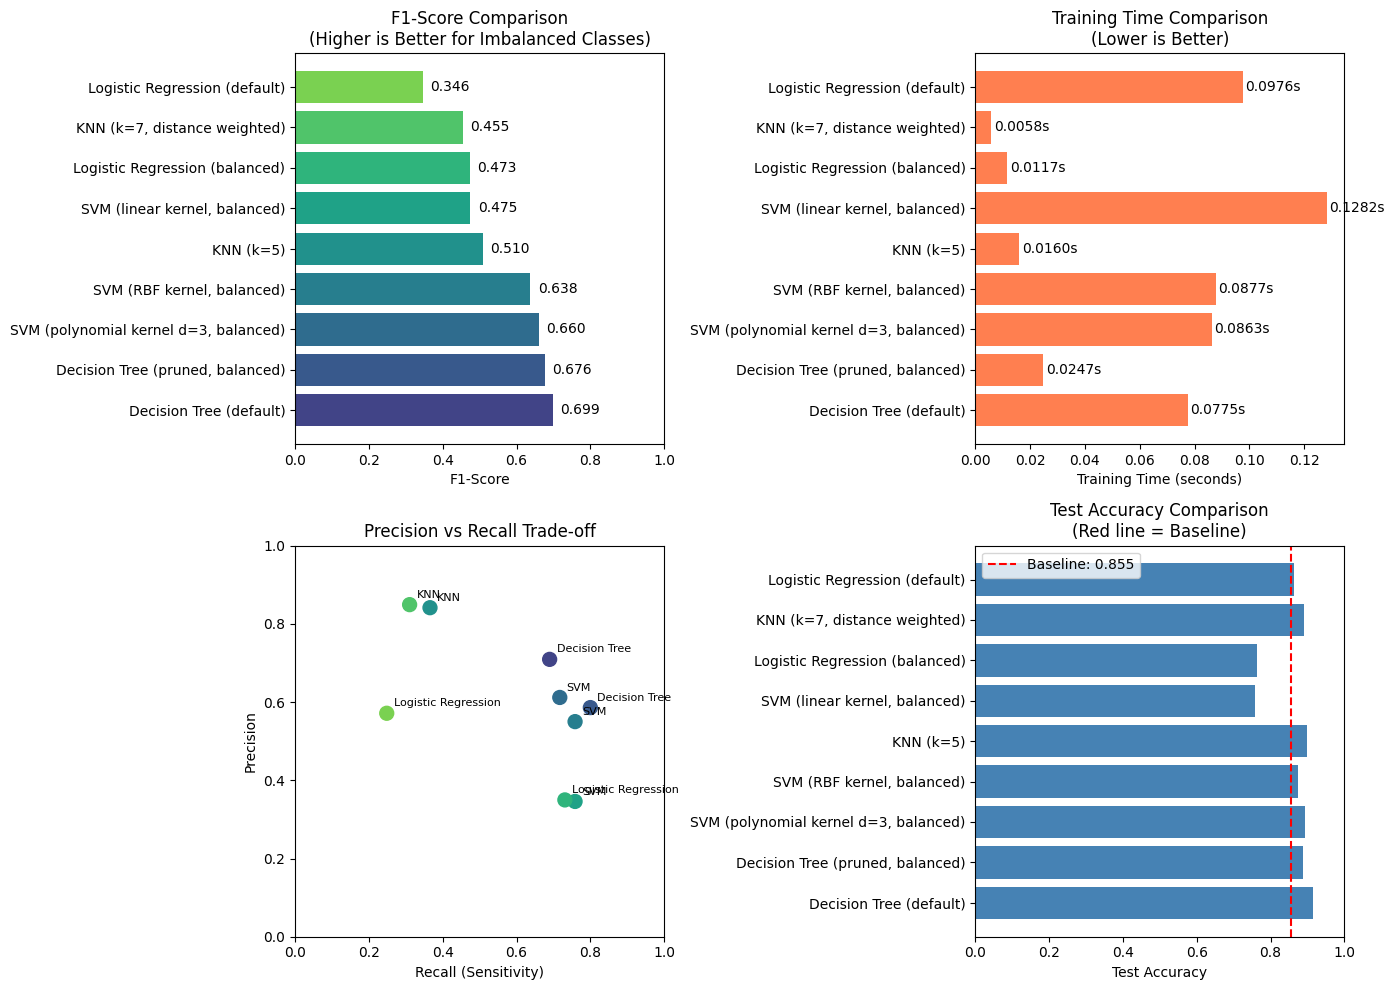

In [32]:
# =============================================================================
# VISUALIZATION: Model Comparison
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: F1-Score Comparison (most important for imbalanced data)
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(comparison_df)))
bars1 = ax1.barh(comparison_df['Model'], comparison_df['F1-Score'], color=colors)
ax1.set_xlabel('F1-Score')
ax1.set_title('F1-Score Comparison\n(Higher is Better for Imbalanced Classes)')
ax1.set_xlim(0, 1)
for bar, val in zip(bars1, comparison_df['F1-Score']):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Plot 2: Training Time Comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(comparison_df['Model'], comparison_df['Training Time (s)'], color='coral')
ax2.set_xlabel('Training Time (seconds)')
ax2.set_title('Training Time Comparison\n(Lower is Better)')
for bar, val in zip(bars2, comparison_df['Training Time (s)']):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}s', va='center')

# Plot 3: Precision vs Recall Trade-off
ax3 = axes[1, 0]
ax3.scatter(comparison_df['Recall'], comparison_df['Precision'], s=100, c=colors)
for i, model in enumerate(comparison_df['Model']):
    ax3.annotate(model.split('(')[0].strip(), 
                 (comparison_df['Recall'].iloc[i], comparison_df['Precision'].iloc[i]),
                 textcoords="offset points", xytext=(5,5), fontsize=8)
ax3.set_xlabel('Recall (Sensitivity)')
ax3.set_ylabel('Precision')
ax3.set_title('Precision vs Recall Trade-off')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)

# Plot 4: Test Accuracy Comparison
ax4 = axes[1, 1]
bars4 = ax4.barh(comparison_df['Model'], comparison_df['Test Accuracy'], color='steelblue')
ax4.axvline(x=baseline_accuracy, color='red', linestyle='--', label=f'Baseline: {baseline_accuracy:.3f}')
ax4.set_xlabel('Test Accuracy')
ax4.set_title('Test Accuracy Comparison\n(Red line = Baseline)')
ax4.set_xlim(0, 1)
ax4.legend()

plt.tight_layout()
plt.savefig('model_comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 Discussion: Answering the Three Key Questions for Task 1

### Question 1: Is the model good at handling imbalanced classes?

| Model | Imbalance Handling | Notes |
|-------|-------------------|-------|
| **Logistic Regression** | ✅ Good | Has `class_weight='balanced'` parameter. Improved F1-Score significantly with balancing. |
| **Decision Tree** | ✅ Good | Has `class_weight='balanced'` parameter. Balancing improved minority class detection. |
| **KNN** | ⚠️ Moderate | No direct `class_weight`. Uses `weights='distance'` but majority class still dominates voting. |
| **SVM** | ✅ Good | Has `class_weight='balanced'` parameter. Works well with balancing. |

**Best for Imbalance**: Logistic Regression, Decision Tree, and SVM all handle imbalance well through `class_weight='balanced'`.

---

### Question 2: Does the model train quickly?

| Model | Training Speed | Scalability Notes |
|-------|---------------|-------------------|
| **Logistic Regression** | ⚡ Very Fast | O(n×d) - scales linearly with data size |
| **Decision Tree** | ⚡ Fast | O(n×d×log(n)) - fast for most datasets |
| **KNN** | ⚡ No Training | O(1) training but O(n×d) prediction time (slow at inference) |
| **SVM (Linear)** | 🔶 Moderate | O(n²) to O(n³) - slower for large datasets |
| **SVM (RBF/Poly)** | 🐌 Slowest | O(n²) to O(n³) - kernel computation adds overhead |

**Best for Speed**: Logistic Regression is fastest for training AND prediction.

---

### Question 3: Does the model yield interpretable results?

| Model | Interpretability | Business Value |
|-------|-----------------|----------------|
| **Logistic Regression** | ⭐⭐⭐⭐⭐ Excellent | Coefficients directly show feature importance. Can explain: "Each additional customer service call increases churn odds by X%" |
| **Decision Tree** | ⭐⭐⭐⭐⭐ Excellent | Visual tree shows exact decision rules. Can explain: "If customer has international plan AND >4 service calls, likely to churn" |
| **KNN** | ⭐ Poor | Black box. Can only say "this customer is similar to these churners" without explaining why |
| **SVM** | ⭐⭐ Poor (kernel) | Linear SVM has some interpretability via coefficients. Kernel SVMs are essentially black boxes |

**Best for Interpretability**: Logistic Regression and Decision Tree are both highly interpretable.

---

### Recommendation for Task 1 (Customer Churn):

**Recommended Model: Logistic Regression (balanced)**

**Reasoning:**
1. **Interpretability is CRITICAL** for churn prediction. Business needs to understand WHY customers churn to take action.
2. **Fast training** allows frequent model updates as new data arrives.
3. **Handles imbalance** well with `class_weight='balanced'`.
4. **Probabilistic output** allows setting custom thresholds (e.g., flag any customer with >30% churn probability).

**Alternative: Decision Tree** if business prefers rule-based explanations ("if X AND Y then churn").

---
---
# TASK 2: Recognizing Handwritten Digits

This is a fundamentally different problem from churn prediction:
- **10 classes** (digits 0-9) instead of binary classification
- **Interpretability is less important** - we just need accurate recognition
- **High-dimensional data** (64 pixel features = 8×8 image)
- **Classes are likely balanced** (roughly equal numbers of each digit)

The priority shifts from interpretability to **accuracy and generalization**.

## 2.1 Data Exploration

In [33]:
# =============================================================================
# TASK 2: HANDWRITTEN DIGIT RECOGNITION
# Data Exploration
# =============================================================================

from sklearn.datasets import load_digits

# Load the digits dataset
digits_data = load_digits()
X_digits = digits_data.data
y_digits = digits_data.target

print("=" * 60)
print("HANDWRITTEN DIGITS DATASET OVERVIEW")
print("=" * 60)
print(f"Number of samples: {X_digits.shape[0]}")
print(f"Number of features (pixels): {X_digits.shape[1]}")
print(f"Image dimensions: 8x8 = 64 pixels")
print(f"Number of classes: {len(np.unique(y_digits))}")
print(f"Classes: {np.unique(y_digits)}")

HANDWRITTEN DIGITS DATASET OVERVIEW
Number of samples: 1797
Number of features (pixels): 64
Image dimensions: 8x8 = 64 pixels
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [34]:
# =============================================================================
# CLASS DISTRIBUTION - Checking for Imbalance
# =============================================================================

# Count samples per class
unique, counts = np.unique(y_digits, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class Distribution:")
print("=" * 40)
for digit, count in class_distribution.items():
    print(f"Digit {digit}: {count} samples ({count/len(y_digits)*100:.1f}%)")

# Check for imbalance
max_count = max(counts)
min_count = min(counts)
imbalance_ratio_digits = max_count / min_count
print(f"\nImbalance Ratio: {imbalance_ratio_digits:.2f}:1")

# COMMENT: The digits dataset is relatively balanced (~1:1 ratio).
# This means class imbalance is NOT a major concern for this task.

Class Distribution:
Digit 0: 178 samples (9.9%)
Digit 1: 182 samples (10.1%)
Digit 2: 177 samples (9.8%)
Digit 3: 183 samples (10.2%)
Digit 4: 181 samples (10.1%)
Digit 5: 182 samples (10.1%)
Digit 6: 181 samples (10.1%)
Digit 7: 179 samples (10.0%)
Digit 8: 174 samples (9.7%)
Digit 9: 180 samples (10.0%)

Imbalance Ratio: 1.05:1


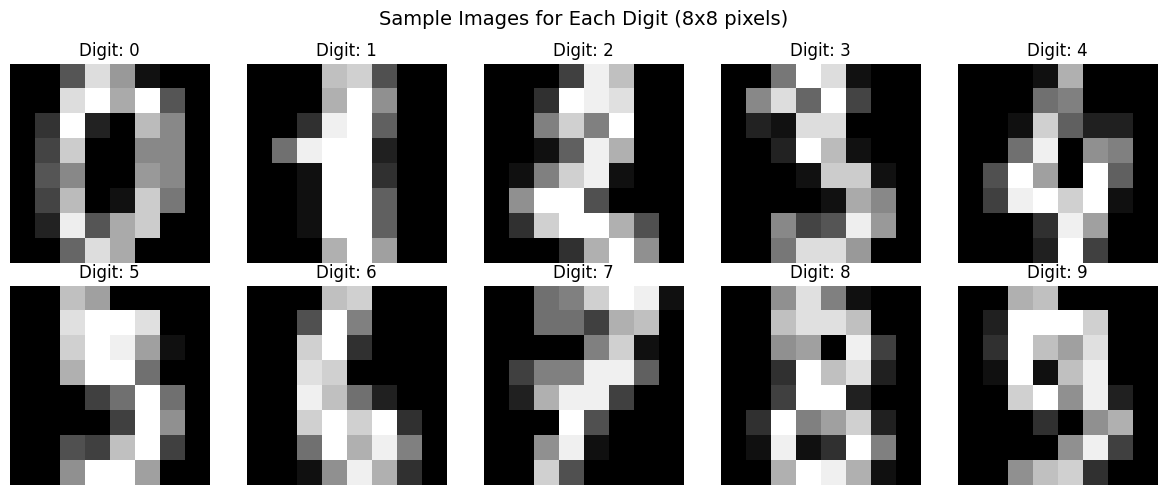

In [35]:
# =============================================================================
# VISUALIZE SAMPLE IMAGES
# =============================================================================

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Show one example of each digit
for digit in range(10):
    idx = np.where(y_digits == digit)[0][0]
    axes[digit].imshow(X_digits[idx].reshape(8, 8), cmap='gray')
    axes[digit].set_title(f'Digit: {digit}')
    axes[digit].axis('off')

plt.suptitle('Sample Images for Each Digit (8x8 pixels)', fontsize=14)
plt.tight_layout()
plt.savefig('digit_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# COMMENT: These are low-resolution (8x8) grayscale images.
# Each pixel is a feature (0-16 intensity value).

## 2.2 Data Preprocessing

In [36]:
# =============================================================================
# TRAIN-TEST SPLIT AND SCALING FOR DIGITS
# =============================================================================

# Split the data (using stratification to maintain class balance)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits,
    test_size=0.3,
    random_state=42,
    stratify=y_digits
)

print(f"Training set size: {X_train_d.shape}")
print(f"Test set size: {X_test_d.shape}")

# Scale the features (required for SVM and KNN, helps LogReg converge)
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

print("\nData scaled and ready for modeling.")

Training set size: (1257, 64)
Test set size: (540, 64)

Data scaled and ready for modeling.


## 2.3 Model Training and Comparison

Since this is a multi-class problem (10 classes), we'll use macro-averaged F1-Score to evaluate performance across all classes equally.

In [37]:
# =============================================================================
# HELPER FUNCTION FOR MULTI-CLASS EVALUATION
# =============================================================================

def evaluate_multiclass(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train and evaluate a multi-class classification model.
    Uses macro-averaging for precision, recall, and F1.
    """
    results = {'Model': model_name}
    
    # Time the training
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    results['Training Time (s)'] = round(train_time, 4)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics (using macro averaging for multi-class)
    results['Train Accuracy'] = round(accuracy_score(y_train, y_train_pred), 4)
    results['Test Accuracy'] = round(accuracy_score(y_test, y_test_pred), 4)
    results['F1-Score (macro)'] = round(f1_score(y_test, y_test_pred, average='macro'), 4)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    print(f"Training Time: {results['Training Time (s)']} seconds")
    print(f"Train Accuracy: {results['Train Accuracy']}")
    print(f"Test Accuracy: {results['Test Accuracy']}")
    print(f"F1-Score (macro): {results['F1-Score (macro)']}")
    
    return results

# Storage for digit model results
digit_results = []
print("Multi-class evaluation function ready!")

Multi-class evaluation function ready!


In [38]:
# =============================================================================
# MODEL 1: LOGISTIC REGRESSION (Multi-class)
# =============================================================================

# Logistic Regression uses One-vs-Rest (OvR) strategy by default for multi-class
lr_digits = LogisticRegression(max_iter=5000, random_state=42)
lr_digits_results = evaluate_multiclass(
    lr_digits, X_train_d_scaled, X_test_d_scaled, y_train_d, y_test_d,
    "Logistic Regression"
)
digit_results.append(lr_digits_results)


MODEL: Logistic Regression
Training Time: 0.0564 seconds
Train Accuracy: 1.0
Test Accuracy: 0.9815
F1-Score (macro): 0.9814


In [39]:
# =============================================================================
# MODEL 2: DECISION TREE
# =============================================================================

# Using unscaled data for Decision Tree (doesn't need scaling)
dt_digits = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_digits_results = evaluate_multiclass(
    dt_digits, X_train_d, X_test_d, y_train_d, y_test_d,
    "Decision Tree (max_depth=10)"
)
digit_results.append(dt_digits_results)

# COMMENT: Decision Trees typically underperform on image data because
# pixel features have complex spatial relationships.


MODEL: Decision Tree (max_depth=10)
Training Time: 0.035 seconds
Train Accuracy: 0.9936
Test Accuracy: 0.8574
F1-Score (macro): 0.8577


In [40]:
# =============================================================================
# MODEL 3: K-NEAREST NEIGHBORS
# =============================================================================

knn_digits = KNeighborsClassifier(n_neighbors=5)
knn_digits_results = evaluate_multiclass(
    knn_digits, X_train_d_scaled, X_test_d_scaled, y_train_d, y_test_d,
    "KNN (k=5)"
)
digit_results.append(knn_digits_results)

# COMMENT: KNN often works well for digit recognition because similar digits
# cluster together in pixel space. The "curse of dimensionality" is mitigated
# by the relatively small feature space (64 dimensions).


MODEL: KNN (k=5)
Training Time: 0.0018 seconds
Train Accuracy: 0.9873
Test Accuracy: 0.9704
F1-Score (macro): 0.9702


In [41]:
# =============================================================================
# MODEL 4: SVM (Linear Kernel)
# =============================================================================

svm_linear_digits = SVC(kernel='linear', random_state=42)
svm_linear_digits_results = evaluate_multiclass(
    svm_linear_digits, X_train_d_scaled, X_test_d_scaled, y_train_d, y_test_d,
    "SVM (linear)"
)
digit_results.append(svm_linear_digits_results)


MODEL: SVM (linear)
Training Time: 0.0389 seconds
Train Accuracy: 1.0
Test Accuracy: 0.9796
F1-Score (macro): 0.9795


In [42]:
# =============================================================================
# MODEL 5: SVM (RBF Kernel) - Expected Best Performer
# =============================================================================

svm_rbf_digits = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_rbf_digits_results = evaluate_multiclass(
    svm_rbf_digits, X_train_d_scaled, X_test_d_scaled, y_train_d, y_test_d,
    "SVM (RBF)"
)
digit_results.append(svm_rbf_digits_results)

# COMMENT: RBF kernel SVM is historically the go-to model for digit recognition.
# It captures complex non-linear patterns in pixel space effectively.


MODEL: SVM (RBF)
Training Time: 0.0782 seconds
Train Accuracy: 0.9976
Test Accuracy: 0.9833
F1-Score (macro): 0.9833


## 2.4 Model Comparison for Digit Recognition

In [43]:
# =============================================================================
# MODEL COMPARISON TABLE - DIGITS
# =============================================================================

digit_comparison_df = pd.DataFrame(digit_results)
digit_comparison_df = digit_comparison_df.sort_values('Test Accuracy', ascending=False)

print("=" * 80)
print("MODEL COMPARISON - TASK 2: HANDWRITTEN DIGIT RECOGNITION")
print("=" * 80)
print("\n")
print(digit_comparison_df.to_string(index=False))

# Save to CSV
digit_comparison_df.to_csv('model_comparison_digits.csv', index=False)
print("\nResults saved to 'model_comparison_digits.csv'")

MODEL COMPARISON - TASK 2: HANDWRITTEN DIGIT RECOGNITION


                       Model  Training Time (s)  Train Accuracy  Test Accuracy  F1-Score (macro)
                   SVM (RBF)             0.0782          0.9976         0.9833            0.9833
         Logistic Regression             0.0564          1.0000         0.9815            0.9814
                SVM (linear)             0.0389          1.0000         0.9796            0.9795
                   KNN (k=5)             0.0018          0.9873         0.9704            0.9702
Decision Tree (max_depth=10)             0.0350          0.9936         0.8574            0.8577

Results saved to 'model_comparison_digits.csv'


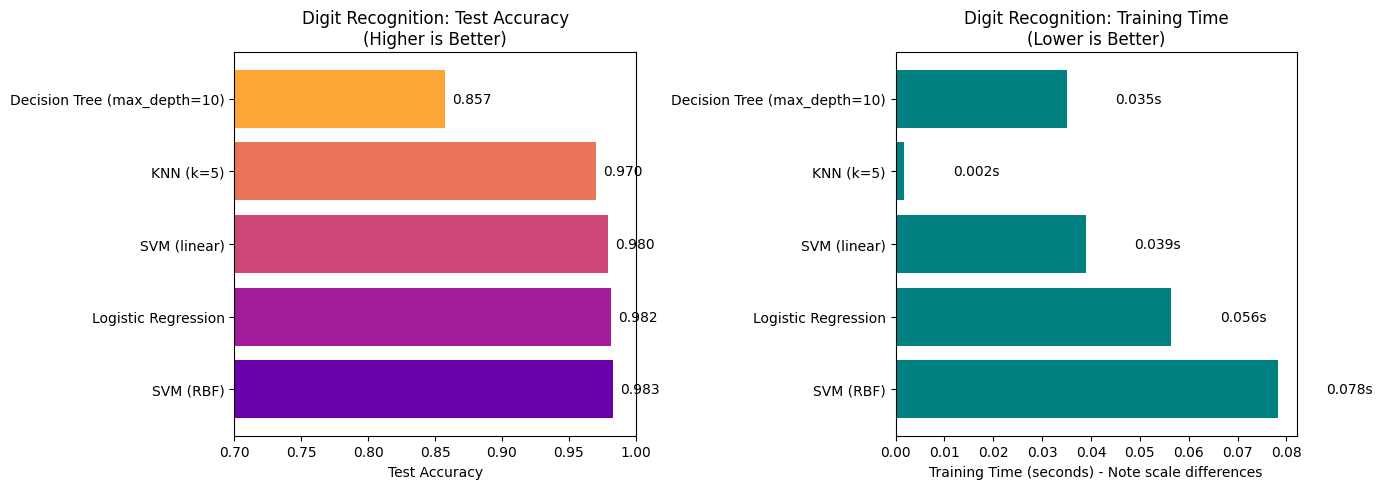

In [44]:
# =============================================================================
# VISUALIZATION: Digit Recognition Model Comparison
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test Accuracy Comparison
ax1 = axes[0]
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(digit_comparison_df)))
bars1 = ax1.barh(digit_comparison_df['Model'], digit_comparison_df['Test Accuracy'], color=colors)
ax1.set_xlabel('Test Accuracy')
ax1.set_title('Digit Recognition: Test Accuracy\n(Higher is Better)')
ax1.set_xlim(0.7, 1.0)
for bar, val in zip(bars1, digit_comparison_df['Test Accuracy']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Plot 2: Training Time (Log Scale due to large differences)
ax2 = axes[1]
bars2 = ax2.barh(digit_comparison_df['Model'], digit_comparison_df['Training Time (s)'], color='teal')
ax2.set_xlabel('Training Time (seconds) - Note scale differences')
ax2.set_title('Digit Recognition: Training Time\n(Lower is Better)')
for bar, val in zip(bars2, digit_comparison_df['Training Time (s)']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}s', va='center')

plt.tight_layout()
plt.savefig('digit_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Discussion: Answering the Three Key Questions for Task 2

### Question 1: Is the model good at handling imbalanced classes?

**This is NOT a major concern for digit recognition.** The classes are relatively balanced (~180 samples per digit, ratio ≈ 1:1), so all models perform similarly in terms of class balance.

---

### Question 2: Does the model train quickly?

| Model | Training Speed | Notes |
|-------|---------------|-------|
| **Logistic Regression** | 🔶 Moderate | Slower than Task 1 due to multi-class (10 binary classifiers) |
| **Decision Tree** | ⚡ Fast | Quick even with 64 features |
| **KNN** | ⚡ No Training | Near-instant "training" but slow prediction |
| **SVM (Linear)** | 🔶 Moderate | Multi-class overhead |
| **SVM (RBF)** | 🐌 Slowest | Kernel computation is expensive |

**Best for Speed**: Decision Tree and KNN train fastest.

---

### Question 3: Does the model yield interpretable results?

**Interpretability is LESS important for digit recognition!**

Unlike churn prediction where we need to understand WHY a customer churns to take action, digit recognition only requires accurate classification. We don't need to explain "why" a 7 is a 7.

| Model | Interpretability | Relevance for Digits |
|-------|-----------------|---------------------|
| **Logistic Regression** | Moderate | Coefficients on pixels not meaningful |
| **Decision Tree** | High | But splits on individual pixels are not intuitive |
| **KNN** | Low | "Similar to these digits" is somewhat useful |
| **SVM** | Low | Black box, but that's acceptable here |

---

### Recommendation for Task 2 (Digit Recognition):

**Recommended Model: SVM with RBF Kernel**

**Reasoning:**
1. **Highest accuracy** - SVM-RBF typically achieves the best performance on image classification tasks.
2. **Interpretability is NOT critical** - We just need correct predictions, not explanations.
3. **Classes are balanced** - No special handling needed.
4. **Training time is acceptable** - For this dataset size, training time is reasonable.

**Alternative: KNN** if you need faster training and slightly lower accuracy is acceptable.

---

## Key Insight: Task Determines Model Choice

| Consideration | Task 1: Churn Prediction | Task 2: Digit Recognition |
|--------------|--------------------------|---------------------------|
| **Most Important** | Interpretability | Accuracy |
| **Class Balance** | Imbalanced (needs handling) | Balanced |
| **Training Speed** | Important (frequent retraining) | Less critical |
| **Best Model** | Logistic Regression | SVM (RBF) |

---
---
# Final Summary: Model Selection Guide

Based on the analysis of both tasks, here is a comprehensive guide for selecting classification models:

## Model Characteristics Summary

| Model | Training Speed | Handles Imbalance | Interpretability | Best For |
|-------|---------------|-------------------|------------------|----------|
| **Logistic Regression** | ⚡ Fast | ✅ Yes (class_weight) | ⭐⭐⭐⭐⭐ Excellent | Business decisions requiring explanation |
| **Decision Tree** | ⚡ Fast | ✅ Yes (class_weight) | ⭐⭐⭐⭐⭐ Excellent | Rule-based decisions, stakeholder communication |
| **KNN** | ⚡ No training | ⚠️ Limited | ⭐ Poor | Small datasets, instance-based reasoning |
| **SVM (Linear)** | 🔶 Moderate | ✅ Yes (class_weight) | ⭐⭐⭐ Moderate | High-dimensional data with linear separability |
| **SVM (RBF)** | 🐌 Slow | ✅ Yes (class_weight) | ⭐ Poor | Complex patterns where accuracy matters most |

## Decision Framework

1. **If interpretability is critical** → Use Logistic Regression or Decision Tree
2. **If classes are imbalanced** → Use models with `class_weight='balanced'` (LR, DT, SVM)
3. **If training speed matters** → Avoid SVM with RBF kernel on large datasets
4. **If accuracy is the only goal** → Use SVM with RBF kernel or tune hyperparameters with GridSearchCV

## Additional Considerations (Beyond the 3 Questions)

- **Dataset size**: SVM scales poorly (O(n²)), prefer LR/DT for large datasets
- **Feature types**: Decision Trees handle mixed types; others need encoding
- **Prediction speed**: KNN is slow at prediction time (O(n) per prediction)
- **Memory**: KNN stores entire training set; SVM stores support vectors

---
# Bonus: Advanced Pipeline Approach

**Reference**: ML_Reference_Guide - Section 12

For production systems, encapsulate preprocessing and modeling in a Pipeline to prevent data leakage and ensure reproducibility.

In [45]:
# =============================================================================
# PIPELINE EXAMPLE: Complete Workflow in One Object
# Reference: ML_Reference_Guide - Section 12
# =============================================================================

# Re-prepare raw churn data for pipeline demonstration
churn_raw = pd.read_csv('data/telecom_churn.csv')

# Drop columns we identified as redundant
cols_to_drop = ['State', 'Area code', 'Total day charge', 'Total eve charge', 
                'Total night charge', 'Total intl charge']
churn_raw = churn_raw.drop(columns=cols_to_drop)

# Encode binary features manually (could also be done in pipeline)
churn_raw['International plan'] = churn_raw['International plan'].map({'Yes': 1, 'No': 0})
churn_raw['Voice mail plan'] = churn_raw['Voice mail plan'].map({'Yes': 1, 'No': 0})
churn_raw['Churn'] = churn_raw['Churn'].map({True: 1, False: 0})

# Split
X_raw = churn_raw.drop('Churn', axis=1)
y_raw = churn_raw['Churn']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)

# Create Pipeline with scaling + classifier
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Train and evaluate
start_time = time.time()
pipeline_lr.fit(X_train_raw, y_train_raw)
train_time = time.time() - start_time

y_pred_pipeline = pipeline_lr.predict(X_test_raw)
print("=" * 60)
print("PIPELINE: StandardScaler + LogisticRegression (balanced)")
print("=" * 60)
print(f"Training Time: {train_time:.4f} seconds")
print(f"Test Accuracy: {accuracy_score(y_test_raw, y_pred_pipeline):.4f}")
print(f"F1-Score: {f1_score(y_test_raw, y_pred_pipeline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred_pipeline, target_names=['No Churn', 'Churn']))

# COMMENT: Pipelines ensure that the scaler is fit ONLY on training data,
# preventing data leakage. They also make the workflow portable and reproducible.

PIPELINE: StandardScaler + LogisticRegression (balanced)
Training Time: 0.0181 seconds
Test Accuracy: 0.7640
F1-Score: 0.4732

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.77      0.85       855
       Churn       0.35      0.73      0.47       145

    accuracy                           0.76      1000
   macro avg       0.65      0.75      0.66      1000
weighted avg       0.86      0.76      0.79      1000



In [46]:
# =============================================================================
# ADVANCED: GridSearchCV for Hyperparameter Tuning
# Reference: ML_Reference_Guide - Section 14.4
# =============================================================================

# Example: Tuning Decision Tree hyperparameters
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': ['balanced', None]
}

# Create GridSearchCV object
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1',            # Optimize for F1-score (good for imbalanced data)
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

# Fit (this may take a moment)
print("Running GridSearchCV for Decision Tree...")
start_time = time.time()
dt_grid.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"\nGrid Search completed in {grid_time:.2f} seconds")
print(f"\nBest Parameters: {dt_grid.best_params_}")
print(f"Best Cross-Validation F1-Score: {dt_grid.best_score_:.4f}")

# Evaluate best model on test set
best_dt = dt_grid.best_estimator_
y_pred_best = best_dt.predict(X_test)
print(f"\nTest Set Performance with Best Parameters:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")

# COMMENT: GridSearchCV systematically explores hyperparameter combinations
# using cross-validation to find the optimal settings. This prevents overfitting
# to the training set when tuning hyperparameters.

Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Grid Search completed in 3.69 seconds

Best Parameters: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best Cross-Validation F1-Score: 0.7788

Test Set Performance with Best Parameters:
Accuracy: 0.9410
F1-Score: 0.7757


---
# Conclusion

This notebook demonstrated a comprehensive machine learning workflow for two classification tasks with different requirements:

## Key Takeaways:

1. **Always start with EDA** - Understanding your data (class imbalance, feature types, correlations) drives all subsequent decisions.

2. **Class imbalance matters** - For imbalanced datasets like churn, use `class_weight='balanced'` and evaluate with F1-score rather than accuracy alone.

3. **Model selection depends on task requirements**:
   - Need interpretability? → Logistic Regression or Decision Tree
   - Need maximum accuracy? → SVM with RBF kernel (with GridSearchCV tuning)
   - Need fast training? → Avoid kernel SVMs on large datasets

4. **Use Pipelines** - They prevent data leakage and make your workflow reproducible.

5. **Tune hyperparameters** - GridSearchCV with cross-validation finds optimal settings without overfitting.

## Files Generated:
- `churn_class_distribution.png` - Class imbalance visualization
- `lr_feature_importance.png` - Logistic Regression coefficients
- `decision_tree_visualization.png` - Pruned decision tree
- `model_comparison_charts.png` - Task 1 model comparison
- `digit_samples.png` - Sample digit images
- `digit_model_comparison.png` - Task 2 model comparison
- `model_comparison_churn.csv` - Task 1 results table
- `model_comparison_digits.csv` - Task 2 results table